# Case 4

# Do models react differently to changes in latent space size?

## Purpose of this notebook

This notebook demonstrates one of the central findings of the thesis:

> The latent-space size most suitablr for a VAE depends on how much temporal context its architecture already carries — a feed-forward model with no memory needs a larger bottleneck to represent seasonal structure than a recurrent model whose hidden state already carries most of that trajectory.

The thesis studies anomaly detection in streaming ERA5 weather data. It compares the impact of different configurations (VAE architecture, streaming and feature manipulation methods, latent dimensionality) on VAEs with different deep learning models as encoder/decoder.

This testcase focuses on **contextual anomalies** (locally-plausible values that are abnormal for the season) with no cyclic time features supplied, so any seasonal structure has to come from the latent code alone.

---

## What is being compared?

The notebook runs eight variants — two architectures, each at four latent dimensions:

| Variant | Latent dimension (Z) | Meaning |
|---|---:|---|
| **MLP-VAE** | 3 | Smallest bottleneck tested. |
| **MLP-VAE** | 8 | |
| **MLP-VAE** | 24 | |
| **MLP-VAE** | 48 | Largest bottleneck tested. |
| **LSTM-VAE** | 3 | Smallest bottleneck tested. |
| **LSTM-VAE** | 8 | |
| **LSTM-VAE** | 24 | |
| **LSTM-VAE** | 48 | Largest bottleneck tested. |

MLP-VAE has no memory of previous timesteps — its latent code is the model's only way to represent "what time of year is this". LSTM-VAE's recurrence already carries most of the seasonal trajectory forward, so its latent code mainly needs to encode the residual.

## Findings being illustrated

The thesis found that MLP-VAE needs a much larger latent dimension (Z=48) than at Z=3 to detect contextual anomalies well, because it has no other way to represent seasonal structure. LSTM-VAE, by contrast, is expected to be far less sensitive to Z — its recurrence already carries most of the seasonal trajectory, so a small latent code is enough to encode the residual.

This reduced notebook uses the full-scale ERA5 export by default (see `case01_clean_baseline.ipynb` for why), so results should be directionally close to the thesis, though exact metric values are not expected to match (single seed, this repo's own port of the training code). The important result is the **relative pattern**: MLP-VAE's F1 should rise substantially from Z=3 to Z=48, while LSTM-VAE's F1 should stay comparatively flat across the same range.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run the eight latent-dimension variants on the same contextual-anomaly dataset.
4. Collect F1, AUC, precision, recall, and confusion-matrix counts.
5. Plot F1 as a function of latent dimension, split by architecture.

### Expected runtime

Window-based runs use the GPU when available. All eight variants share the same dataset; MLP-VAE runs are typically faster than LSTM-VAE.

### Before running

This notebook reads code and data from a **private GitHub repository**. You must:

1. Have permission to access the read-only repository with a fine-grained GitHub token.
2. In Colab, open the **Secrets** panel using the key icon.
3. Add the secret `GITHUB_TOKEN`.
4. Enable **Notebook access** for that secret.
5. Select **Runtime → Change runtime type → GPU**.
6. Choose **Runtime → Run all**.

The source ERA5 data and its licence information are described in `DATA_LICENSE.md`.

# Run Case

### Check GPU availability

In [8]:
%matplotlib inline
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.11.0+cu128
CUDA available: True
Selected device: Tesla T4


### Import and/or load Repo

In [9]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError(
            "The Colab secret GITHUB_TOKEN is unavailable. "
            "Open the key icon in the left sidebar, add the token, "
            "and enable Notebook access."
        )

    if not REPO_DIR.exists():
        # Use an askpass helper so the token is not stored in the Git remote URL.
        askpass = Path("/content/git_askpass.sh")
        askpass.write_text(
            '#!/bin/sh\n'
            'case "$1" in\n'
            '  *Username*) echo "x-access-token" ;;\n'
            '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
            'esac\n'
        )
        askpass.chmod(0o700)

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"

        try:
            subprocess.run(
                ["git", "clone", REPO_URL, str(REPO_DIR)],
                check=True,
                env=env,
            )
        finally:
            askpass.unlink(missing_ok=True)

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("run_regression.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: /content/repo
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.


### Step 1 — Configure the run

In [10]:
import os
import yaml

CASE_ID = "case04_latent_dimension"
SESSION_DIR = "runs/regression"
OUTPUT_DIR = f"{SESSION_DIR}/{CASE_ID}"

# Edit this directly — works the same locally and on Colab:
#   "full_split_files" (default) -> anom_types/contextual.yaml's own default —
#                      full-scale contextual data, pre-split into a
#                      warmup-only file (shared with case01 — the warmup
#                      portion is anomaly-free and identical regardless of
#                      anomaly type) and a test-only file with the
#                      contextual anomalies injected. Committed to the repo.
#   "mini_50pct"    -> the in-repo 377,784-row ERA5 slice (~50% of full-scale).
#                      Committed to the repo.
#   "mini_28pct"    -> the in-repo 210,384-row ERA5 slice (~28% of full-scale).
#                      Committed to the repo.
DATA_SOURCE = "full_split_files"

_DATA_SOURCE_LAYERS = {
    "full_split_files": None,   # anom_types/contextual.yaml's own default — no extra layer needed
    "mini_50pct": "../../modules/data_source/mini_50pct_contextual.yaml",
    "mini_28pct": "../../modules/data_source/mini_28pct_contextual.yaml",
}

_suite_source_path = f"notebooks/cases/{CASE_ID}_suite.yaml"
_suite_dir = os.path.dirname(os.path.abspath(_suite_source_path))

def _resolve(path):
    # base_config / config_layers entries are relative paths meant to be
    # read relative to the suite file's own directory (notebooks/cases/).
    # Resolving them to absolute paths here — rather than leaving them
    # relative — means the resolved copy stays correct no matter how deep
    # under OUTPUT_DIR it ends up being written.
    return path if os.path.isabs(path) else os.path.normpath(os.path.join(_suite_dir, path))

_data_source_layer = _DATA_SOURCE_LAYERS[DATA_SOURCE]

with open(_suite_source_path) as f:
    _suite = yaml.safe_load(f)

_suite["base_config"] = _resolve(_suite["base_config"])
for _run in _suite["runs"]:
    _layers = [_resolve(p) for p in _run["config_layers"]]
    if _data_source_layer:
        _layers.append(_resolve(_data_source_layer))
    _run["config_layers"] = _layers

# Written under OUTPUT_DIR (runs/, already gitignored and read-write) rather
# than notebooks/ (source-controlled, meant to stay read-only) — os.makedirs
# because OUTPUT_DIR won't exist yet on a fresh run.
os.makedirs(OUTPUT_DIR, exist_ok=True)
SUITE_PATH = f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved.yaml"
with open(SUITE_PATH, "w") as f:
    yaml.safe_dump(_suite, f, sort_keys=False)

print(f"DATA_SOURCE = {DATA_SOURCE!r} -> {_data_source_layer}")

DATA_SOURCE = 'full_split_files' -> None


#### Configuration file

The notebooks test suites combines a shared ERA5 configuration (`modules/era5_common.yaml`) with the architecture, anomaly type, stream mode, and latent-dimension settings for each run.

`DATA_SOURCE` may be configured to choose other datasets from the era5 data directory.
The default is `"full_split_files"`, which is the full-scale contextual-anomaly data, where warmup and test files are split (`data/era5/full_scale/split/era5_clean_warmup.csv` and `data/era5/full_scale/split/era5_contextual_test.csv`).

All variants use the same base configuration and evaluation procedure. The intended comparison is therefore the effect of **latent dimensionality** on each architecture's contextual-anomaly detection.

#### Output Directory

During execution, the script creates a separate run directory in the repo for each variant under `OUTPUT_DIR` (`runs/regression/case04_latent_dimension` by default).

`notebooks/cases/case04_latent_dimension_suite.yaml` layers `modules/era5_common.yaml` with the architecture / anomaly-type / stream-mode / feature-engineering fragments and the per-run latent-dimension override (see the suite file for the exact overrides).

### Step 2 Run the testsuite

### Command:

In [11]:
!python run_regression.py {SUITE_PATH} \
    --session {SESSION_DIR} --skip-existing

[suite] log     : /content/repo/runs/regression/suite.log
[suite] suite   : /content/repo/runs/regression/case04_latent_dimension/case04_latent_dimension_suite_resolved.yaml
[suite] session : /content/repo/runs/regression
[suite] base cfg: /content/repo/modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0]  (1 slot(s))
[suite] 8 run(s) planned:
  [  1] MLP_Z3  [case04_latent_dimension/case04_latent_dimension_suite_resolved]  (module: regression.run_trial)
  [  2] MLP_Z8  [case04_latent_dimension/case04_latent_dimension_suite_resolved]  (module: regression.run_trial)
  [  3] MLP_Z24  [case04_latent_dimension/case04_latent_dimension_suite_resolved]  (module: regression.run_trial)
  [  4] MLP_Z48  [case04_latent_dimension/case04_latent_dimension_suite_resolved]  (module: regression.run_trial)
  [  5] LSTM_Z3  [case04_latent_dimension/case04_latent_dimension_suite_resolved]  (module: regression.run_trial)
  [  6] LSTM_Z8  [case04_latent_dimension/case04_late

### Step 3 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table
- anomaly-score histograms
- an F1 comparison across variants
- confusion-matrix summaries
- seed-stability diagnostics, where applicable.

These outputs are saved under `OUTPUT_DIR/cross_compare/`.

### Command:

In [12]:
!python cross_compare.py {OUTPUT_DIR}

[cross] session : runs/regression/case04_latent_dimension
[cross] output  : runs/regression/case04_latent_dimension/cross_compare
[cross] 8 run(s) found:
  LSTM_Contextual_24                                  arch=LSTM  anomaly=Contextual  cyclic=False  mode=window
  LSTM_Contextual_3                                   arch=LSTM  anomaly=Contextual  cyclic=False  mode=window
  LSTM_Contextual_48                                  arch=LSTM  anomaly=Contextual  cyclic=False  mode=window
  LSTM_Contextual_8                                   arch=LSTM  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_24                                   arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_3                                    arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_48                                   arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_8                                    arch=MLP  anomaly=

### Step 4 — Quantitative Results

### Command:

In [13]:
import pandas as pd
from IPython.display import display

performance_path = f"{OUTPUT_DIR}/cross_compare/performance_table.csv"
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

perf["variant"] = perf["variant"].astype(int)

print("Comparison of latent-dimension variants")
display(
    perf[columns]
    .sort_values(["arch", "variant"])
    .reset_index(drop=True)
    .style.format({
        "f1": "{:.3f}",
        "auc": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
    })
)

Comparison of latent-dimension variants


,run_name,arch,anomaly,variant,f1,auc,precision,recall,tp,fp,fn
0,LSTM_Contextual_3,LSTM,Contextual,3,0.483,0.905,0.689,0.372,326,147,551
1,LSTM_Contextual_8,LSTM,Contextual,8,0.597,0.939,0.625,0.571,501,300,376
2,LSTM_Contextual_24,LSTM,Contextual,24,0.396,0.914,0.267,0.762,668,1831,209
3,LSTM_Contextual_48,LSTM,Contextual,48,0.426,0.916,0.306,0.700,614,1394,263
4,MLP_Contextual_3,MLP,Contextual,3,0.061,0.708,0.194,0.036,32,133,845
5,MLP_Contextual_8,MLP,Contextual,8,0.323,0.854,0.548,0.229,201,166,676
6,MLP_Contextual_24,MLP,Contextual,24,0.500,0.905,0.638,0.410,360,204,517
7,MLP_Contextual_48,MLP,Contextual,48,0.609,0.932,0.621,0.596,523,319,354


#### Expected qualitative pattern

```text
MLP-VAE:  F1(Z=3)  <<  F1(Z=8)  <  F1(Z=24)  <=  F1(Z=48)     (rising with Z)
LSTM-VAE: F1(Z=3)  <  F1(Z=8)  >  F1(Z=24) >  F1(Z=48)
```

The testcase is successful when the thesis's findings are observed. MLP-VAE shows a clear F1 improvement from low to high Z while LSTM-VAE achieves decent results with Z=3, peaks at z=8 and degredates at higher Zs.

### Step 5 — Qualitative support (Plots)

#### F1 vs. latent dimension

##### Command:

F1 vs latent_dim, split by architecture:


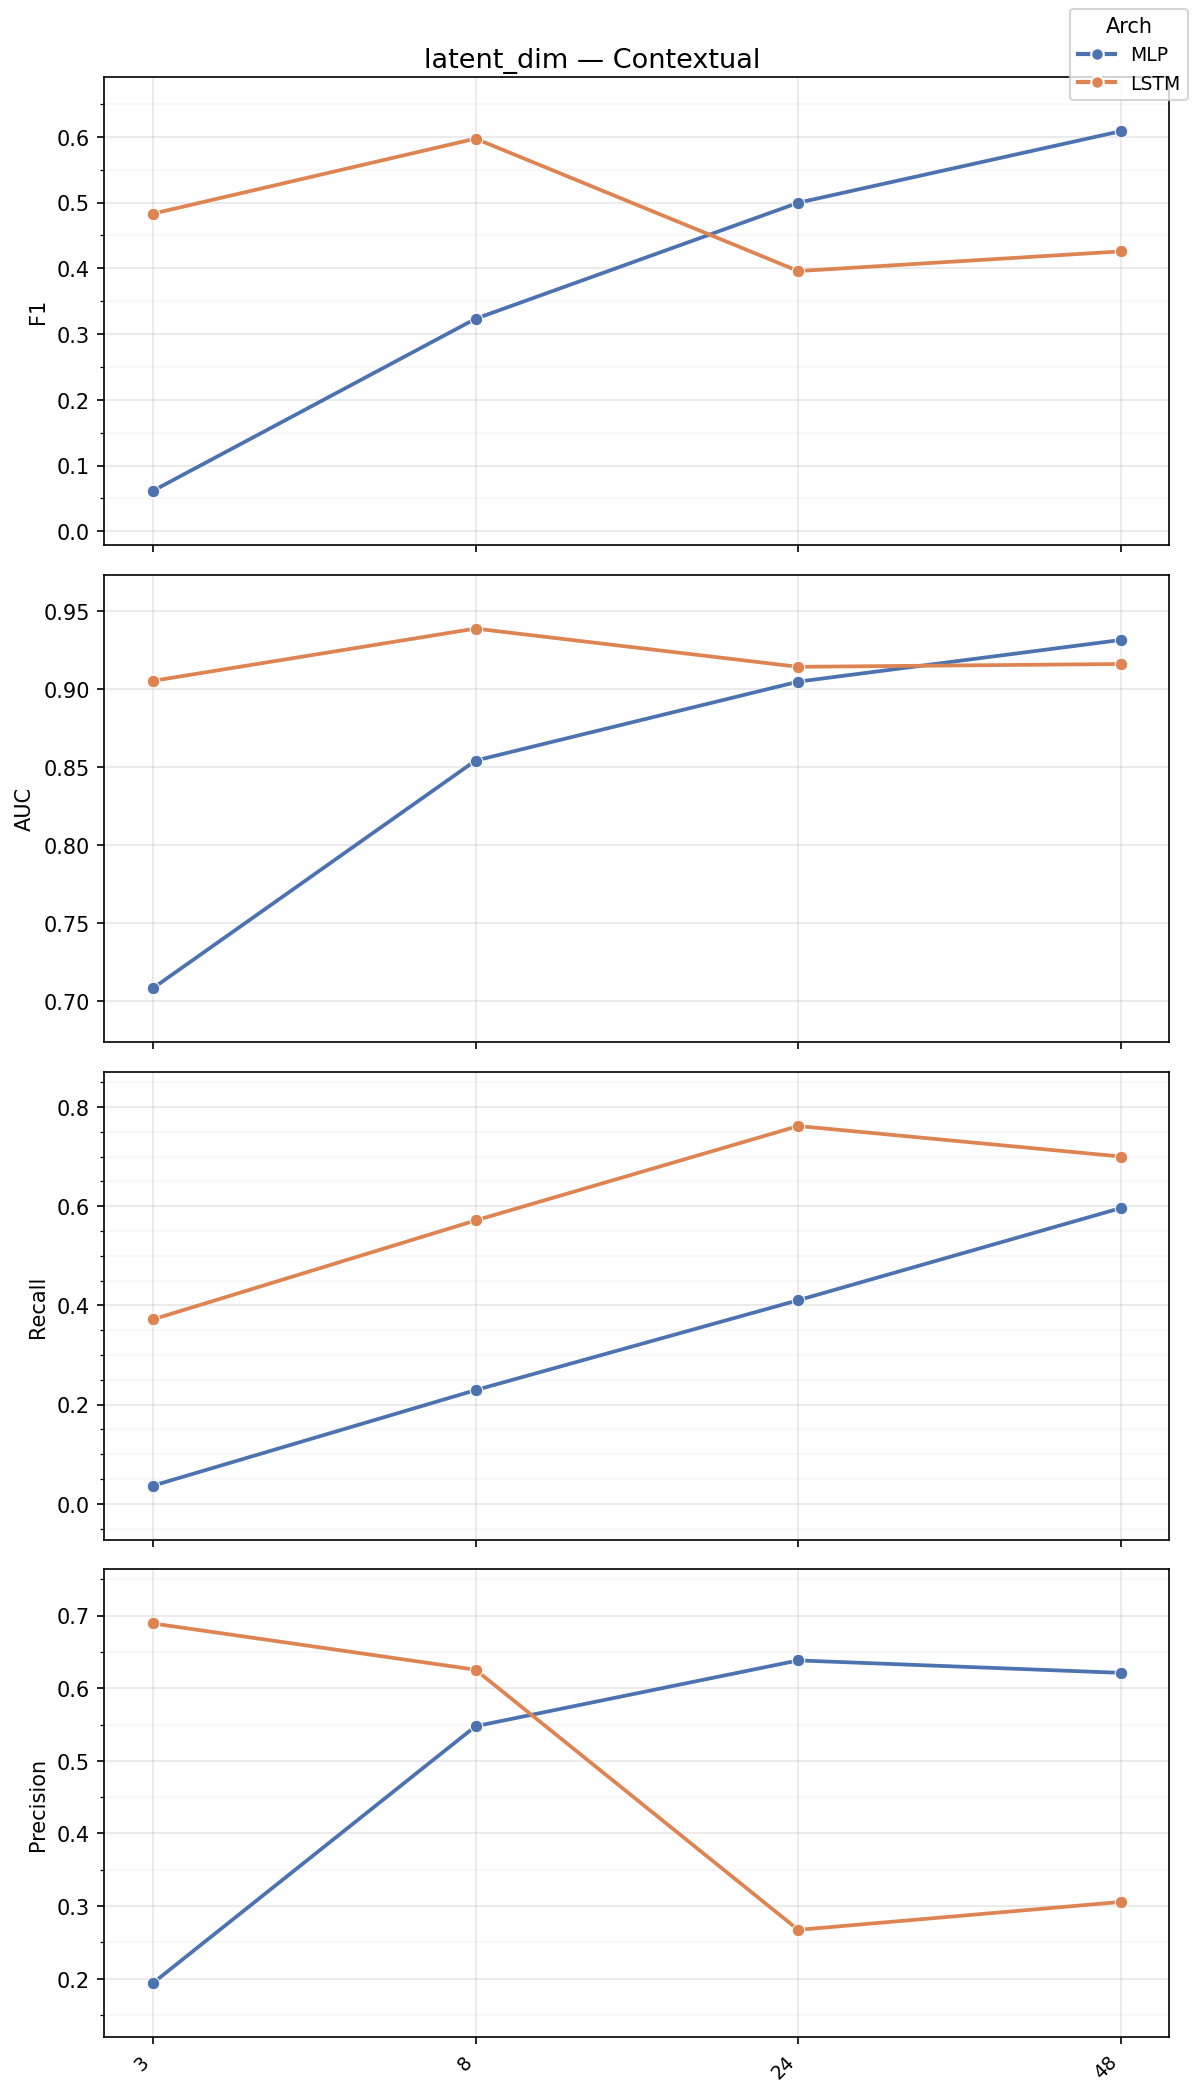

In [14]:
# Display the key comparison plot(s) inline
import glob
from IPython.display import Image, display

print("F1 vs latent_dim, split by architecture:")
for p in sorted(glob.glob(f"{OUTPUT_DIR}/cross_compare/contextual/section_lines_latent_dim.png")):
    display(Image(filename=p))

F1, Precision and Recall plots against latent dimension results (3, 8, 24, 48). MLP-VAE's line should climb steeply for both Precision and Recall an the dimension size increases. LSTM-VAE's F1 line is less sensitive.

#### The plot can indicate, among other things:

1. Whether MLP-VAE's F1 rises meaningfully as Z grows from 3 to 48.
2. Whether LSTM-VAE's F1 is comparatively insensitive to Z across the same range.
3. At what latent dimension (if any) each architecture's F1 plateaus.

### Main takeaway

The latent-space size a VAE needs depends on how much temporal context is already carried by the architecture itself. A feed-forward model with no memory of previous timesteps has no way to represent seasonal structure except through its latent code, so it needs a large bottleneck to detect contextual anomalies well. A recurrent model's hidden state already carries most of the seasonal trajectory forward, so its latent code mainly needs to encode the residual — a small Z is enough.

## Scope of this testcase

This notebook is a compact demonstration, not a full reproduction of every latent-dimensionality experiment reported in the thesis. With `DATA_SOURCE = "full_split_files"` (the default) it runs on the full-scale contextual-anomaly data. With `DATA_SOURCE = "mini_50pct"` / `"mini_28pct"` a shorter ERA5 interval is used instead — useful for a quick check, but see `case01_clean_baseline.ipynb` for why it can give different results than the full-scale data.

Conclusions should be based on the **direction and consistency of the F1-vs-latent_dim trend per architecture**, rather than exact numerical agreement with the thesis figures (single seed, this repo's own port of the training code).

For the complete experiment definitions, consult the thesis section associated with **4.3.2 Effect of Latent Dimensionality**, together with the YAML configuration files used by this suite.